# Design 3: Algorithm A2 evaluation dynamics

From `literature-notes/main-project-idea.txt`: an expansion of Design 2 with two changes: (1) chunks are encoded as `{song_id, evaluation}` instead of `{song_id, complexity}`; (2) Algorithm A2 replaces Algorithm A as the basis for simulation. Everything else (the cyclic von Mises environment) stays the same as Design 2.

**Algorithm A2**, per `src/model.py`'s `evaluate_a2()`:
- `x` = predicted_activation (Algorithm A step 1's output)
- `f(x) = 1/e^x`
- `y` = signed difference between this song's current and previous actual-activation readings (its own last two activations)
- `g(y)` = mirrored sigmoid = `1/(1+e^y)`
- `evaluation = g(y) * f(x)`, encoded as the new chunk's second slot

`evaluation` is undefined on a song's 1st exposure (no chunk yet) and 2nd (no prior activation reading to diff against) -- 0.0 is encoded as a bootstrap placeholder for those two exposures (confirmed with Mark). Since each distinct evaluation value creates a new chunk, a song accumulates many chunks over time (one per past instance of experiencing it) -- consistent with the project's IBL framing, but this makes the unconstrained "predict next chunk" retrieval scale roughly quadratically with number of exposures (confirmed empirically: 500->0.4s, 1000->1.6s, 2000->7s, 4000->31s, 10000->212s). NUM_EXPOSURES defaults to 2000 here for fast iteration; raise it if you want a longer run and don't mind waiting.

`complexity` is still tracked per-song at the environment level (for future inverted-U analysis) even though it's no longer stored in the memory chunk itself.

Change parameters below and re-run to explore. Note: set NOISE=0 for a deterministic run (Mark's note in main-project-idea.txt).

In [23]:
import math
import sys
sys.path.insert(0, "..")
import matplotlib.pyplot as plt

from run_simulation import sweep_center, von_mises_weights, run_design3

NUM_SONGS = 100
NUM_EXPOSURES = 1000
WINDOW = 10
SEED = 42
NUM_CYCLES = 10
KAPPA = 4.0
SWEEP_TYPE = "rotate"
NOISE = 0.00   # set to 0 for a deterministic run
DECAY = 0.5

ANNOTATE_SONGS = False    # set True to label points with their song_id
ANNOTATE_MAX_LABELS = 1000  # evenly-spaced label count when ANNOTATE_SONGS is True

angles = [2 * math.pi * i / NUM_SONGS for i in range(NUM_SONGS)]
period = NUM_EXPOSURES / NUM_CYCLES

## Controller visualization
Same cyclic von Mises environment as Design 2 -- six snapshots across one cycle.

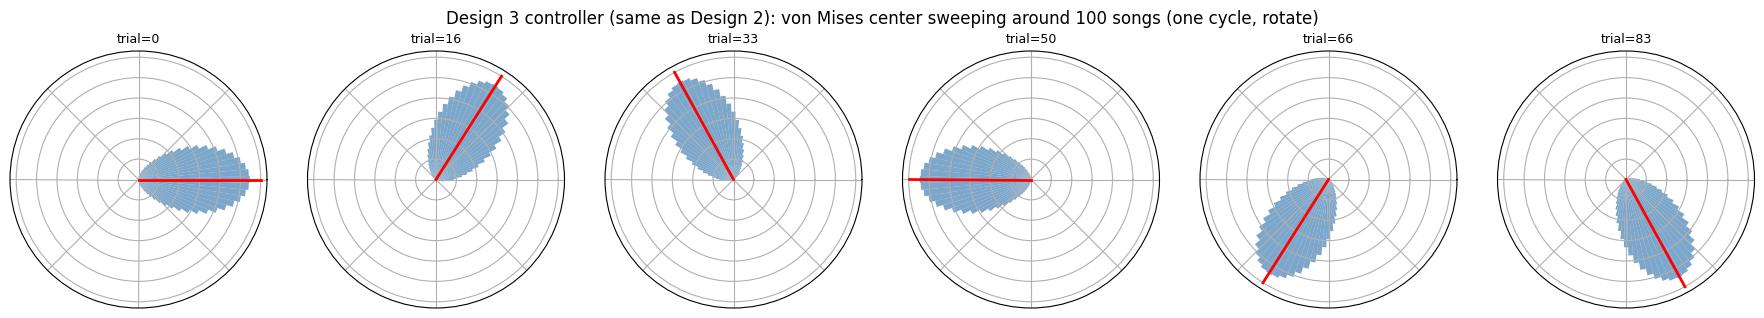

In [24]:
n_snapshots = 6
snapshot_trials = [int(k * period / n_snapshots) for k in range(n_snapshots)]

fig, axes = plt.subplots(1, n_snapshots, figsize=(3 * n_snapshots, 3.2),
                          subplot_kw={"projection": "polar"})
for ax, t in zip(axes, snapshot_trials):
    mu = sweep_center(t, NUM_EXPOSURES, NUM_CYCLES, SWEEP_TYPE)
    weights = von_mises_weights(angles, mu, KAPPA)
    ax.bar(angles, weights, width=2 * math.pi / NUM_SONGS, color="steelblue", alpha=0.7)
    ax.plot([mu, mu], [0, max(weights) * 1.1], color="red", linewidth=2)
    ax.set_title(f"trial={t}", fontsize=9)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
fig.suptitle(f"Design 3 controller (same as Design 2): von Mises center sweeping around {NUM_SONGS} songs (one cycle, {SWEEP_TYPE})")
fig.tight_layout()
fig.savefig("../results/figures/design3_controller_snapshots.png", dpi=150)

## Resulting evaluation time series

In [25]:
df = run_design3(num_songs=NUM_SONGS, num_exposures=NUM_EXPOSURES, window=WINDOW,
                  kappa=KAPPA, num_cycles=NUM_CYCLES, sweep_type=SWEEP_TYPE,
                  noise=NOISE, decay=DECAY, seed=SEED,
                  config_path="../config.yaml",
                  output_path="../results/data/design3_evaluation_timeseries.csv")
df.describe()

/Users/morr/Computing/Claude-Test_1/Automation_v0/.venv/lib/python3.9/site-packages/pyactup.py:149: UserWarning: A noise of 0.0 and temperature of None will make the temperature too low; setting temperature to 1
  warn(f"A noise of {noise} and temperature of None will make the temperature "


,predicted_activation,actual_activation,aesthetic_basis,x,f_x,y,g_y,evaluation,trial,complexity,mu,evaluation_rolling_mean
count,900.000000,900.000000,900.000000,900.000000,900.000000,800.000000,800.000000,800.000000,900.000000,900.000000,900.000000,517.000000
mean,0.011769,-1.704796,1.716566,0.011769,0.989275,0.020906,0.496892,0.492751,544.075556,5.011111,34.185275,0.502725
std,0.046249,0.756371,0.751930,0.046249,0.040699,1.082576,0.224890,0.223752,268.192609,2.692611,16.851039,0.062352
min,0.000000,-3.107304,0.000000,0.000000,0.666667,-2.610441,0.068469,0.067106,12.000000,1.000000,0.753982,0.323429
25%,0.000000,-2.287355,1.151293,0.000000,1.000000,-0.746128,0.295127,0.292678,322.750000,3.000000,20.278981,0.460295
50%,0.000000,-2.031299,2.038905,0.000000,1.000000,-0.071141,0.517778,0.515000,549.500000,5.000000,34.526103,0.503394
75%,0.000000,-1.098612,2.289910,0.000000,1.000000,0.870618,0.678334,0.670034,774.250000,7.000000,48.647562,0.541942
max,0.405465,0.405465,3.163253,0.405465,1.000000,2.610441,0.931531,0.931531,999.000000,10.000000,62.769021,0.733730


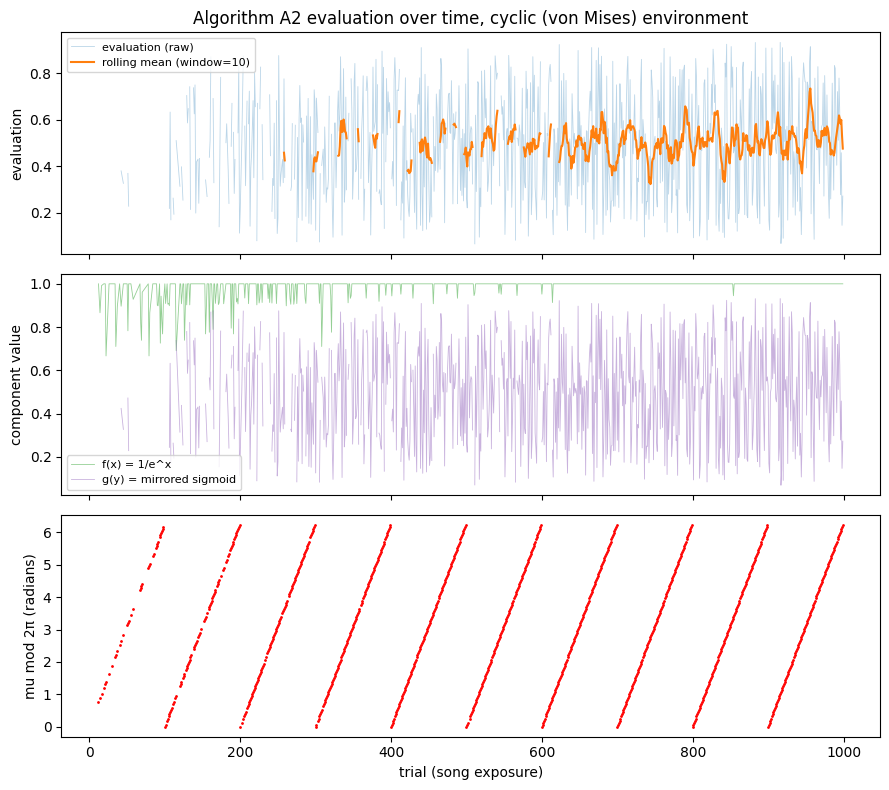

In [26]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(9, 8), sharex=True)

ax1.plot(df["trial"], df["evaluation"], alpha=0.3, linewidth=0.6,
         color="tab:blue", label="evaluation (raw)")
ax1.plot(df["trial"], df["evaluation_rolling_mean"], linewidth=1.5,
         color="tab:orange", label=f"rolling mean (window={WINDOW})")

if ANNOTATE_SONGS:
    labeled = df.dropna(subset=["evaluation"])
    step = max(1, len(labeled) // ANNOTATE_MAX_LABELS)
    for _, row in labeled.iloc[::step].iterrows():
        ax1.annotate(row["actual_song_id"], (row["trial"], row["evaluation"]),
                     fontsize=7, rotation=90, textcoords="offset points", xytext=(0, 5))

ax1.set_ylabel("evaluation")
ax1.set_title("Algorithm A2 evaluation over time, cyclic (von Mises) environment")
ax1.legend(fontsize=8)

ax2.plot(df["trial"], df["f_x"], alpha=0.5, linewidth=0.6, color="tab:green", label="f(x) = 1/e^x")
ax2.plot(df["trial"], df["g_y"], alpha=0.5, linewidth=0.6, color="tab:purple", label="g(y) = mirrored sigmoid")
ax2.set_ylabel("component value")
ax2.legend(fontsize=8)

mu_wrapped = df["mu"] % (2 * math.pi)
ax3.scatter(df["trial"], mu_wrapped, color="red", s=1)
ax3.set_ylabel("mu mod 2π (radians)")
ax3.set_xlabel("trial (song exposure)")

fig.tight_layout()
fig.savefig("../results/figures/design3_evaluation_timeseries.png", dpi=150)

`evaluation` combines `f(x)` (how strongly the predicted chunk's activation is favored -- decays as predicted activation rises) and `g(y)` (the mirrored sigmoid of this song's own activation change -- pulled toward 0.5 when its activation barely changed, pushed toward 1 when it *dropped* and toward 0 when it *rose*, since g is decreasing in y). Check whether one component visibly dominates the shape of the top panel, or whether the interaction between them is what's driving it.